In [170]:
import pandas as pd
import numpy as np
from scipy.stats import norm, t
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
sys.path.append("/Users/willneuner/Desktop/FINTECH545") 

In [17]:
# DISTRIBUTIONS (NORMAL AND T)
from risk_management import distributions

# mu_vector, covariance_matrix = fit_multivariate_normal_dist(x: pd.DataFrame)

# mu, sigma, nu = fit_univariate_t_dist(x)

# alpha, betas, mu, sigma, nu = t_regression(X: pd.DataFrame, y:pd.Series, add_constant:bool = True, print_summary = False)

In [18]:
# MEASUREMENTS (CORRELATION, COVARIANCE, FACTORIZATIONS, RETURNS)
from risk_management import measurements

# corr = compute_correlation(x:pd.DataFrame, method="pearson", drop_missing = False, exponentially_weighted = False, lambda_ = 0.97, ddof: int =1)

# cov = compute_covariance(x:pd.DataFrame, drop_missing = False, exponentially_weighted = False, lambda_ = 0.97, ddof:int=1)

# cov = compute_covariance_with_ew_corr(x: pd.DataFrame, corr_lambda, var_lambda)

# psd = near_psd(A: pd.DataFrame, epsilon = 0.0)
# psd = higham_psd(A: pd.DataFrame, tolerance = 1e-8, max_iterations= 100_000)

# A = cholesky_factor(x:pd.DataFrame)

# returns = compute_returns(x: pd.DataFrame, return_type = "arithmetic")


In [19]:
# RISK METRICS (VAR, ES)
from risk_management import risk_metrics

# NOTE -> all of these assume that X was a set of RETURNS, not prices

# abs_VaR, rel_VaR = univariate_normal_VaR(mean: float, std: float, alpha = 0.05)

# nu, mu, sigma = t.fit(x)
# abs_VaR, rel_VaR = univariate_t_VaR(mu: float, sigma: float, nu: float, alpha: float = 0.05)

# abs_ES, diff_ES = expected_shortfall_normal(mu:float, sigma: float, alpha = 0.05)

# mu, sigma, nu = fit_univariate_t_dist(x)
# abs_ES, diff_ES = expected_shortfall_t(mu: float, sigma: float, nu: float, alpha: float = 0.05)



In [20]:
## SIMULATIONS
from risk_management import simulations

# NOTE -> all of these assume that X was a set of RETURNS, not prices

# simulation_data = normal_monte_carlo_simulation(mean_vector, covariance_matrix, n_sims, fix_method, seed=1234) # len(cov), n_sims

# simulation_data = pca_monte_carlo_simulation(mean_vector, covariance_matrix, n_sims, explained_threshold = 0.99, seed=1234) # len(cov), n_sims

# current_prices = vector of start prices of assets, holdings = vector of how many of each asset we have
# abs_VaR, rel_VaR = monte_carlo_VaR_sim(mean_vector, covariance_matrix, current_prices, holdings, n_draws, return_type = "arithmetic", alpha = 0.05, seed = 1234) 

# sim_dataframe = VaR_ES_2_level_sim_from_copula(sample_data: pd.DataFrame, holdings: np.array, prices: np.array, fix_method, n_sims = 100_000, alpha=0.05, seed=1234)

In [21]:
from risk_management import goodness_of_fit

# r2, adjr2, Aic, Aicc, BIC

from risk_management import asset_pricing

# European, American binary, American Discontinuous div

from risk_management import portfolio_construction

# risk parity, weighted risk parity, max sharpe, efficient frontier, 

from risk_management import risk_attribution
# ex_post attribution, ex_post factor attribution


### Question 1

In [71]:
data_1 = pd.read_csv("problem1.csv")
returns = data_1.to_numpy()

In [31]:
mean, cov = distributions.fit_multivariate_normal_dist(data_1)

In [ ]:
### NOTE -> could do this using the binary tree form since we only have 1 day to expiry

In [72]:
S = 100
days = 255
T = 1/days
rfr = 0.04
div = 0
b = rfr-div

In [74]:
S_1 = S * (1+returns)

In [92]:
def sim_option_payoff(S_values, X, T, r, call: bool = True):
    if call:
        return np.exp(-r*T)*(np.sum(S_values[S_values >= X]- X) / len(S_values))
    if not call:
        return np.exp(-r*T)*(np.sum(X - S_values[S_values <= X]) / len(S_values))

In [93]:
for X in [99, 100, 101]:
    call_price = sim_option_payoff(S_1, X, T, rfr, True)
    put_price = sim_option_payoff(S_1, X, T, rfr, False)

    print("Strike:", X)
    print("Call price:", call_price)
    print("Put price:", put_price)

Strike: 99
Call price: 1.4734332453286259
Put price: 0.48487134903993795
Strike: 100
Call price: 0.8726852344208567
Put price: 0.8839664876893879
Strike: 101
Call price: 0.4701682745245145
Put price: 1.481292677350265


In [96]:
# TODO -> this may not be the way to do it?
call_prices = []
implied_volatilities = []
for X in range(95, 106):
    call_price = sim_option_payoff(S_1, X, T, rfr, True)
    # print("Strike:", X)
    # print("Call price:", call_price)
    call_prices.append(call_price)
    i_vol = asset_pricing.implied_vol_gbsm(call_price, S, X, T, rfr, b, option_type="call")
    implied_volatilities.append(i_vol)

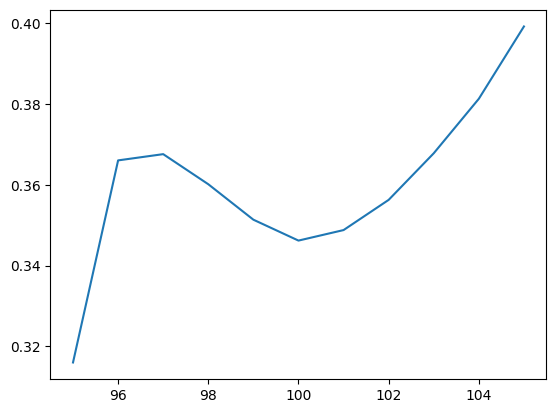

In [98]:
plt.plot(range(95, 106), implied_volatilities)

### Question 2

In [251]:
data_2 = pd.read_csv("problem2.csv")

In [252]:
data_2.iloc[-1] # Current day is 11-22

Date    2025-11-21
SPY     659.030029
Name: 725, dtype: object

In [253]:
SPY_prices = data_2['SPY'].to_numpy()
SPY_returns = measurements.compute_returns(data_2.set_index("Date"), return_type="arithmetic")

In [254]:
days = 255
# call option
X_call = 665

call_price = 7.05

# put option
X_put = 655
put_price = 7.69


T = 10/days # expiration = 12/5/2025
rfr = 0.04
div = 0.0109
b = rfr-div

In [255]:
# a. find best fit model between normal and t

mean, cov = distributions.fit_multivariate_normal_dist(SPY_returns)
mu, sigma, nu = distributions.fit_univariate_t_dist(SPY_returns)

In [256]:
mean_spy, std = float(mean.iloc[0]), np.sqrt(float(cov.iloc[0,0]))

In [257]:
mean_spy, std, mu, sigma, nu

(0.0008546463321495879,
 np.float64(0.009774292186672591),
 np.float64(0.00116833897941659),
 np.float64(0.006530386934998567),
 np.float64(3.8523329682117664))

In [258]:
n = len(SPY_returns)
params_norm = {"loc": mean_spy, "scale": std}

LL_norm = goodness_of_fit.log_likelihood(norm.pdf, params_norm, SPY_returns)
aicc_norm = goodness_of_fit.aicc(2, LL_norm, n)

params_t = {"loc": mean_spy, "scale": sigma, "df":nu}
LL_t = goodness_of_fit.log_likelihood(t.pdf, params_t, SPY_returns)
aicc_t = goodness_of_fit.aicc(3, LL_t, n)

bic_norm = goodness_of_fit.bic(2, LL_norm, n)
bic_t = goodness_of_fit.bic(3, LL_t, n)

In [259]:
aicc_norm, aicc_t, bic_norm, bic_t

(np.float64(-4650.121906494044),
 np.float64(-4834.418499511958),
 np.float64(-4640.96618368295),
 np.float64(-4820.693271648642))

In [260]:
SPY_prices[-1]

np.float64(659.030029296875)

In [261]:
# b. Compute implied vol of put and call
S = SPY_prices[-1]
call_i_vol = asset_pricing.implied_vol_gbsm(call_price, S, X_call, T, rfr, b, option_type="call")
put_i_vol = asset_pricing.implied_vol_gbsm(put_price, S, X_put, T, rfr, b, option_type="put")
call_i_vol, put_i_vol

(0.18042710650092886, 0.1908305795166143)

In [274]:
# c. VaR and ES -> NEED TO USE THE FITTED DISTRIBUTION
# n_sims = 10_000
# mean_arr = np.array([mu])
# cov = np.array([[sigma**2]])
# sims = simulations.normal_monte_carlo_simulation(mean_arr, cov, n_sims=n_sims*5, fix_method=measurements.higham_psd)
# five_day_sims = sims.reshape((5, n_sims))

In [279]:
n_sims = 10_000
sims = t.rvs(df=nu, loc=mu, scale=sigma, size=n_sims*5)
five_day_sims = sims.reshape((5, n_sims))
sim_returns = np.prod(1+five_day_sims, axis=0) - 1

In [281]:
portfolio_value = S - call_price + put_price

pnls = []
for five_day_return in tqdm(sim_returns):
    S_new = S * (1+five_day_return)
    
    new_put_price, *_ = asset_pricing.European_GBSM(S_new, X_put, T-5/days, put_i_vol, rfr, b, option_type="put")
    new_call_price, *_ = asset_pricing.European_GBSM(S_new, X_call, T-5/days, call_i_vol, rfr, b, option_type="call")

    pnl = (S_new + new_put_price - new_call_price) - portfolio_value
    pnls.append(pnl)

pnls = np.array(pnls)
VaR = -np.percentile(pnls, 0.05*100)
ES = -np.mean(pnls[pnls <= np.percentile(pnls, 0.05*100)])
VaR_pct = VaR / portfolio_value
ES_pct = ES / portfolio_value

  0%|          | 0/10000 [00:00<?, ?it/s]

In [283]:
VaR, ES

(np.float64(3.5120668796037475), np.float64(4.201076214263073))

In [284]:
VaR_pct, ES_pct, portfolio_value

(np.float64(0.005323975205220657),
 np.float64(0.006368450934084256),
 np.float64(659.6700292968751))

In [271]:
SPY_returns # daily

,SPY
Date,
2023-01-04,0.007720
2023-01-05,-0.011413
2023-01-06,0.022932
2023-01-09,-0.000567
2023-01-10,0.007013
...,...
2025-11-17,-0.009316
2025-11-18,-0.008398
2025-11-19,0.003863


In [270]:
from scipy.optimize import minimize

In [250]:
# d: Portfolio Optimization
portfolio_value = 659.57
rf_holding = rfr * 5/255




In [294]:
X_call = 665
X_put = 655
rfr = 0.04
put_i_vol = 0.1908305795166143
call_i_vol = 0.18042710650092886
div = 0.0109
b = rfr-div
S = 659.030029296875
T = 5/255
rf_holding = rfr * 5/255

call_price = 7.05
put_price = 7.69

portfolio_value = 659.57


def optimization_func(w, sim_returns): 
    p_returns = []
    
    for five_day_return in sim_returns:
        S_new = S * (1+five_day_return)
        new_put_price, *_ = asset_pricing.European_GBSM(S_new, X_put, T, put_i_vol, rfr, b, option_type="put")
        new_call_price, *_ = asset_pricing.European_GBSM(S_new, X_call, T, call_i_vol, rfr, b, option_type="call")

        p_return = ((w[0]*S_new + w[1]*new_put_price + w[2]*new_call_price) - portfolio_value)/portfolio_value
        p_returns.append(p_return)

    p_returns = np.array(p_returns)
    ES = -np.mean(p_returns[p_returns <= np.percentile(p_returns, 0.05*100)])

    return (np.mean(p_returns) - rf_holding) / ES

asset_prices = np.array([S, call_price, put_price])
val_constraint = {'type': 'eq', 'fun': lambda w: (w @ asset_prices) - portfolio_value}
constraints = [val_constraint]

bounds = ((-2, 2),)*3

min_function = lambda x: optimization_func(x, sim_returns[:200])

result = minimize(fun=min_function, x0=np.ones(3)/means.shape[0], method='SLSQP', bounds=bounds, constraints=constraints, options={'ftol': 1e-20, 'maxiter': 1000, 'disp': False})

result.x

array([0.96738387, 2.        , 1.03185691])

In [295]:
p_returns = []
    
for five_day_return in sim_returns:
    S_new = S * (1+five_day_return)
    new_put_price, *_ = asset_pricing.European_GBSM(S_new, X_put, T, put_i_vol, rfr, b, option_type="put")
    new_call_price, *_ = asset_pricing.European_GBSM(S_new, X_call, T, call_i_vol, rfr, b, option_type="call")

    p_return = ((w[0]*S_new + w[1]*new_put_price + w[2]*new_call_price) - portfolio_value)/portfolio_value
    p_returns.append(p_return)

# p_returns = np.array(p_returns)
# ES = -np.mean(p_returns[p_returns <= np.percentile(p_returns, 0.05*100)])


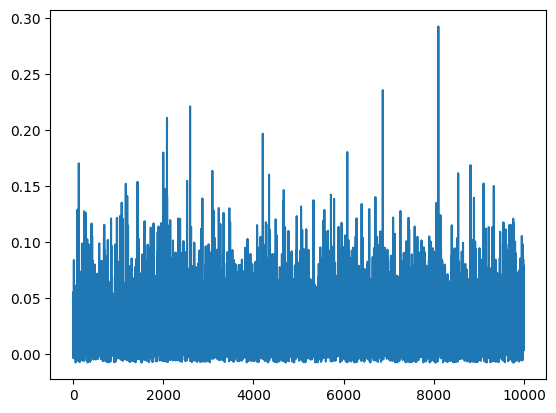

In [297]:
# plt.plot((1+p_returns)*portfolio_value)
plt.plot(p_returns)

In [288]:
np.mean(p_returns), ES

(np.float64(0.0248301422366282), np.float64(0.005605428484638745))

In [ ]:
# w_constraint = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
asset_prices = 
val_constraint = {'type': 'eq', 'fun': lambda w: w @ asset_prices - portfolio_value}
constraints = [val_constraint]

bounds = ((0, None),)*cov.shape[0]


min_function = lambda x: custom_min_func(x, means, cov)

result = minimize(fun=min_function, x0=np.ones(means.shape[0])/means.shape[0], method='SLSQP', bounds=bounds, constraints=constraints, options={'ftol': 1e-20, 'maxiter': 1000, 'disp': False})

return result.x

### Question 3

In [199]:
data_3_is = pd.read_csv("problem3_insample.csv").set_index("Date")
data_3_os = pd.read_csv("problem3_outsample.csv").set_index("Date")

In [200]:
data_3_is.head()

,GOOG,JPM,WMT,AMD,NKE
Date,,,,,
2020-01-31,0.048897,-0.055853,-0.037414,-4.276983e-02,-0.057730
2020-02-29,-0.066168,-0.122771,-0.059481,-3.234044e-02,-0.069284
2020-03-31,-0.131797,-0.224615,0.059832,-7.771561e-16,-0.074289
2020-04-30,0.159828,0.074698,0.069794,1.519349e-01,0.053662
2020-05-31,0.059511,0.016186,0.025139,2.691353e-02,0.133585


array([0.01903477, 0.01406811, 0.01482958, 0.0312393 , 0.00137316])

In [205]:
rfr = 0.04
means = data_3_is.mean().to_numpy()
cov = measurements.compute_covariance(data_3_is, exponentially_weighted=True, lambda_=0.97)

annual_means = (1+means)**12 - 1
annual_cov = cov*12

In [212]:
# a: Max Sharpe and Risk parity
risk_budgets = np.ones_like(annual_means)
sharpe_w = portfolio_construction.compute_max_sharpe_weights(annual_means, annual_cov, rfr, weight_bounds=(0, None))
parity_w = portfolio_construction.compute_risk_parity_weights(annual_cov, risk_budgets, pos_weights=True)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.1385791534693106
            Iterations: 12
            Function evaluations: 73
            Gradient evaluations: 12
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.682414709094283e-18
            Iterations: 22
            Function evaluations: 138
            Gradient evaluations: 22


In [213]:
sharpe_w

array([2.69852943e-01, 7.45201204e-02, 5.30213983e-01, 1.25412954e-01,
       1.57288522e-16])

In [214]:
parity_w

array([0.21344153, 0.20705692, 0.31489376, 0.10069856, 0.16390923])

In [ ]:
# b compare ex-post and ex-ante contributions for both portfolios on out of sample data
os_returns = data_3_os.to_numpy()

In [241]:
cov

,GOOG,JPM,WMT,AMD,NKE
GOOG,0.005719,0.001688,0.000672,0.005840,0.001064
JPM,0.001688,0.005385,0.001001,0.003587,0.002874
WMT,0.000672,0.001001,0.002986,0.001085,0.001979
AMD,0.005840,0.003587,0.001085,0.022504,0.004858
NKE,0.001064,0.002874,0.001979,0.004858,0.008411


In [248]:
# Sharpe Ratio Ex-Ante
# cov = cov.to_numpy()
# ex ante return:
expected_portfolio_return = sharpe_w @ annual_means
asset_return_contribution = sharpe_w * annual_means

# ex ante risk contributions
vol = np.sqrt(sharpe_w.T.dot(cov).dot(sharpe_w))
csd = sharpe_w * (cov.dot(sharpe_w)) / vol

print(asset_return_contribution)
print(csd * np.sqrt(12))
print()
print(expected_portfolio_return, vol*np.sqrt(12))
print()
print(100*asset_return_contribution / expected_portfolio_return)
print(100*csd / vol)

[6.85196782e-02 1.36008105e-02 1.02443377e-01 5.59948079e-02
 2.61144743e-18]
[5.06996468e-02 9.32741969e-03 7.13475368e-02 4.47736013e-02
 2.31421406e-17]

0.24055867379008866 0.176148204697913

[2.84835617e+01 5.65384332e+00 4.25856094e+01 2.32769856e+01
 1.08557608e-15]
[2.87823807e+01 5.29521133e+00 4.05042657e+01 2.54181423e+01
 1.31378805e-14]


In [235]:
# Sharpe Ratio Ex-Post
_, total_portfolio_return, asset_returns, _, _, attributed_returns, risk_attributions, portfolio_vol = risk_attribution.ex_post_attribution(os_returns, sharpe_w)
print(attributed_returns)
print(risk_attributions*np.sqrt(12))
print(total_portfolio_return, portfolio_vol*np.sqrt(12))
print(attributed_returns/total_portfolio_return)
print(risk_attributions / portfolio_vol)

[ 9.17841851e-02  2.86741389e-02  1.47834707e-01  2.27531768e-02
 -9.25595008e-18]
[5.09924605e-02 1.03379813e-02 9.96400115e-02 1.78370020e-02
 2.34711281e-17]
0.29104620757474664 0.1788074553306952
[ 3.15359495e-01  9.85209156e-02  5.07942392e-01  7.81771973e-02
 -3.18023387e-17]
[2.85180841e-01 5.78162766e-02 5.57247523e-01 9.97553595e-02
 1.31264818e-16]


In [249]:
# Risk Parity Ex-Ante
# cov = cov.to_numpy()
# ex ante return:
expected_portfolio_return = parity_w @ annual_means
asset_return_contribution = parity_w * annual_means

# ex ante risk contributions
vol = np.sqrt(parity_w.T.dot(cov).dot(parity_w))
csd = parity_w * (cov.dot(parity_w)) / vol

print(asset_return_contribution)
print(csd * np.sqrt(12))
print()
print(expected_portfolio_return, vol*np.sqrt(12))
print()
print(100*asset_return_contribution / expected_portfolio_return)
print(100*csd / vol)

[0.05419598 0.03779036 0.06084106 0.04496024 0.00272137]
[0.03610197 0.03610197 0.03610197 0.03610197 0.03610197]

0.20050900729814736 0.18050983953772784

[27.02919991 18.84721124 30.34330493 22.42305288  1.35723104]
[20.00000026 20.00000022 20.00000073 19.99999897 19.99999982]


In [236]:
# Risk Parity Ex-Post
_, total_portfolio_return, asset_returns, _, _, attributed_returns, risk_attributions, portfolio_vol = risk_attribution.ex_post_attribution(os_returns, parity_w)
print(attributed_returns)
print(risk_attributions*np.sqrt(12))
print(total_portfolio_return, portfolio_vol*np.sqrt(12))
print(attributed_returns/total_portfolio_return)
print(risk_attributions / portfolio_vol)

[ 0.07438307  0.08240892  0.09013348  0.01888541 -0.00966092]
[0.03918584 0.03558282 0.05168605 0.02049371 0.03593185]
0.25614995911070126 0.18288027931551668
[ 0.29038874  0.32172138  0.3518778   0.07372795 -0.03771587]
[0.21427047 0.19456894 0.28262235 0.11206082 0.19647743]


### Question 4

### Question 5

### Question 6